# 01 - EDA Exploratorio

**Objetivo:** Entender los datos, encontrar problemas y generar hipótesis.

**Nota:** Este notebook es desordenado porque es parte del proceso de descubrimiento.

In [17]:
# Cargo todo lo que necesito sin orden
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargo los datos
df = pd.read_csv('UCI_Credit_Card.csv')

# Renombro para hacer más legible
df.rename(columns={
    'default.payment.next.month': 'DEFAULT',
    'PAY_0': 'PAY_1',  # En el dataset PAY_0 es el mes más reciente
    'LIMIT_BAL': 'LIMITE_CREDITO',
    'SEX': 'SEXO',
    'EDUCATION': 'EDUCACION',
    'MARRIAGE': 'ESTADO_CIVIL',
    'AGE': 'EDAD'
}, inplace=True)

# Veo qué trae
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              30000 non-null  int64  
 1   LIMITE_CREDITO  30000 non-null  float64
 2   SEXO            30000 non-null  int64  
 3   EDUCACION       30000 non-null  int64  
 4   ESTADO_CIVIL    30000 non-null  int64  
 5   EDAD            30000 non-null  int64  
 6   PAY_1           30000 non-null  int64  
 7   PAY_2           30000 non-null  int64  
 8   PAY_3           30000 non-null  int64  
 9   PAY_4           30000 non-null  int64  
 10  PAY_5           30000 non-null  int64  
 11  PAY_6           30000 non-null  int64  
 12  BILL_AMT1       30000 non-null  float64
 13  BILL_AMT2       30000 non-null  float64
 14  BILL_AMT3       30000 non-null  float64
 15  BILL_AMT4       30000 non-null  float64
 16  BILL_AMT5       30000 non-null  float64
 17  BILL_AMT6       30000 non-null 

In [ ]:
# la primera columna es ID, eso no sirve para predecir
df = df.drop('ID', axis=1)

# Veo si hay nulos (parece que no)
df.isnull().sum()


LIMITE_CREDITO    0
SEXO              0
EDUCACION         0
ESTADO_CIVIL      0
EDAD              0
PAY_1             0
PAY_2             0
PAY_3             0
PAY_4             0
PAY_5             0
PAY_6             0
BILL_AMT1         0
BILL_AMT2         0
BILL_AMT3         0
BILL_AMT4         0
BILL_AMT5         0
BILL_AMT6         0
PAY_AMT1          0
PAY_AMT2          0
PAY_AMT3          0
PAY_AMT4          0
PAY_AMT5          0
PAY_AMT6          0
DEFAULT           0
dtype: int64

In [9]:
# ¿Qué es esa columna default.payment.next.month? Es mi variable objetivo!
df['DEFAULT'].value_counts()

DEFAULT
0    23364
1     6636
Name: count, dtype: int64

In [10]:
df['DEFAULT'].value_counts(normalize=True)

DEFAULT
0    0.7788
1    0.2212
Name: proportion, dtype: float64

# Distribución de variables clave

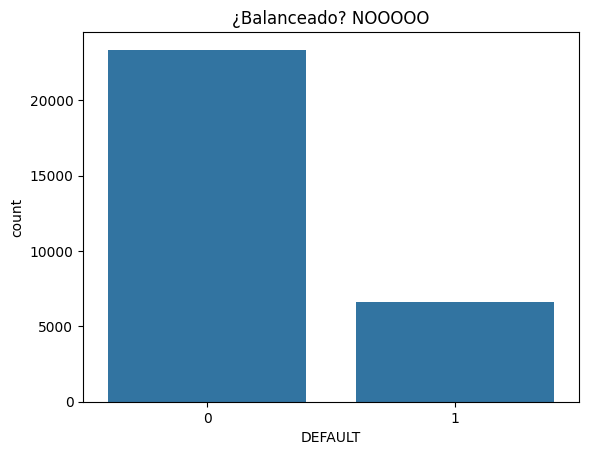

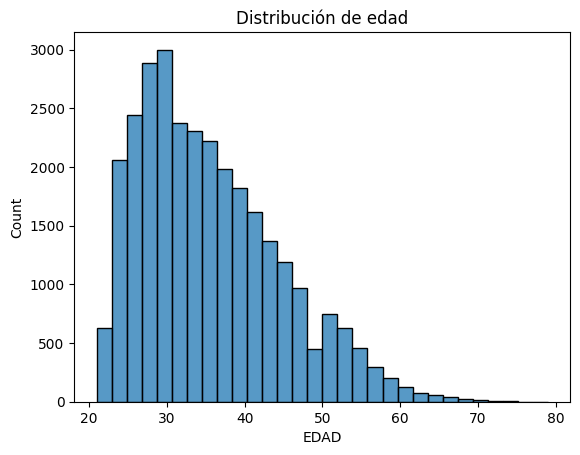

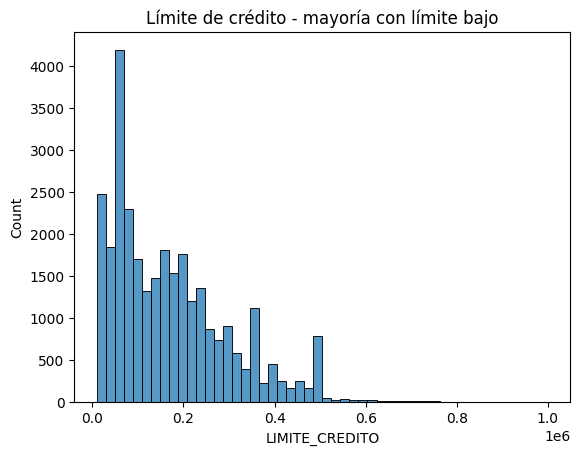

In [11]:
# Mi variable objetivo (DEFAULT)
sns.countplot(data=df, x='DEFAULT')
plt.title('¿Balanceado? NOOOOO')
plt.show()

# Edad (hay gente muy joven y muy vieja?)
sns.histplot(df['EDAD'], bins=30)
plt.title('Distribución de edad')
plt.show()
# Qué raro, hay gente de 80 años con tarjeta?

# Límite de crédito (está sesgado hacia la izquierda)
sns.histplot(df['LIMITE_CREDITO'], bins=50)
plt.title('Límite de crédito - mayoría con límite bajo')
plt.show()

# Historial de pagos

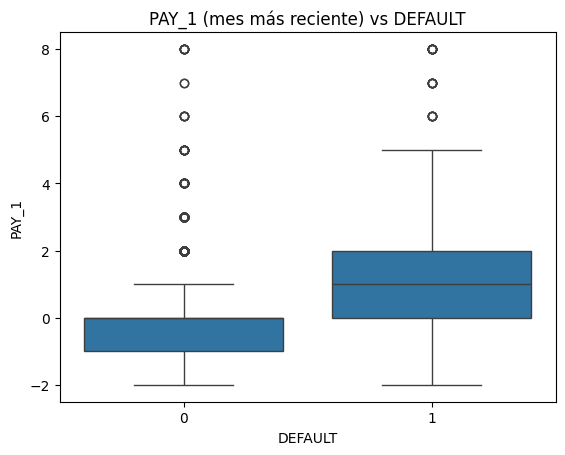

In [12]:
# PAY_1 a PAY_6: -2, -1, 0, 1, 2,...
# -2 = pagó, -1 = pagó, 0 = pagó justo, 1 = atraso 1 mes, etc.

# ¿Los que entran en default tienen PAY_1 más alto?
sns.boxplot(data=df, x='DEFAULT', y='PAY_1')
plt.title('PAY_1 (mes más reciente) vs DEFAULT')
plt.show()
# ¡Clarísimo! Los que fallaron tenían PAY_1 mucho más alto

In [19]:
# 1. Cuántos casos conflictivos hay?
conflictivos = df[(df['PAY_1'] > 1) & (df['DEFAULT'] == 0)]
len(conflictivos)  # ¿Cuántos son?

953

In [20]:
# 2. Ver si esos 953 tienen atraso bajo (ej: PAY_1=2) o alto (PAY_1=8)
df[(df['PAY_1'] > 1) & (df['DEFAULT'] == 0)]['PAY_1'].value_counts()

PAY_1
2    823
3     78
4     24
5     13
8      8
6      5
7      2
Name: count, dtype: int64

# Correlaciones rápidas

In [13]:
# Correlación con DEFAULT
corr = df.corr()['DEFAULT'].sort_values(ascending=False)
corr.head(10)
# PAY_1, PAY_2, ... son los que más correlacionan (negativo = paga bien)

DEFAULT      1.000000
PAY_1        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
EDUCACION    0.028006
EDAD         0.013890
BILL_AMT6   -0.005372
Name: DEFAULT, dtype: float64

# Variables categóricas

In [16]:
# SEXO: 1=hombre, 2=mujer
df.groupby('SEXO')['DEFAULT'].mean()
# ¿Hay diferencia? pequeños

SEXO
1    0.241672
2    0.207763
Name: DEFAULT, dtype: float64

In [15]:
# EDUCACION: 1=posgrado, 2=universidad, 3=secundaria, 4=otros, 0,5,6?
df['EDUCACION'].value_counts().sort_index()
# Hay valores raros: 0, 5, 6 (posible error)

EDUCACION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

In [18]:
df['ESTADO_CIVIL'].value_counts().sort_index()

ESTADO_CIVIL
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

# Conclusiones del EDA

### ✅ Hallazgos clave
1. **Dataset limpio**: 30,000 registros, sin nulos.
2. **Desbalance moderado**: 78% No default vs 22% Default.
3. **El mejor predictor es PAY_1** (correlación 0.32 con DEFAULT).
4. **Clientes con PAY_1 > 0 tienen alta probabilidad de default** (boxplot lo confirma).

### ⚠️ Problemas detectados y decisiones tomadas
| Problema | Decisión |
|----------|----------|
| `EDUCACION` con valores 0,5,6 | Se agruparán en categoría 4 (Otros) en Feature Engineering |
| `ESTADO_CIVIL` con valor 0 | Se agrupará en categoría 3 (Otros) |
| `PAY_1` y DEFAULT inconsistentes (953 casos) | **No se eliminan**. Representan recuperaciones reales de clientes (86% son atraso leve PAY_1=2) |

### 📋 Pendiente para 02_Feature_Engineering
- [ ] Limpiar `EDUCACION` y `ESTADO_CIVIL`
- [ ] Crear variable `MAX_ATRASO` (peor atraso en 6 meses)
- [ ] Crear variable `PROMEDIO_PAGO_RATIO` (pago vs factura)
- [ ] Escalar variables numéricas
- [ ] Aplicar SMOTE o class_weight por desbalance

### 🚀 Próximo paso
Continuar con `02_Feature_Engineering.ipynb`